# Dataset description
## Average lending rate per year

**Source**: Banco de la república

**Download**: [link](https://suameca.banrep.gov.co/descarga-multiple-de-datos/)

# Code
## Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Load data

In [3]:
path = "./data/tasa_colocacion.csv"

df = pd.read_csv(path, encoding="utf-8")

## Clean data

In [7]:
df["Fecha"] = pd.to_datetime(df["Fecha"], dayfirst=True)
df["Fecha"] = df["Fecha"].dt.year

by_year = df.groupby("Fecha").mean()

## Plot

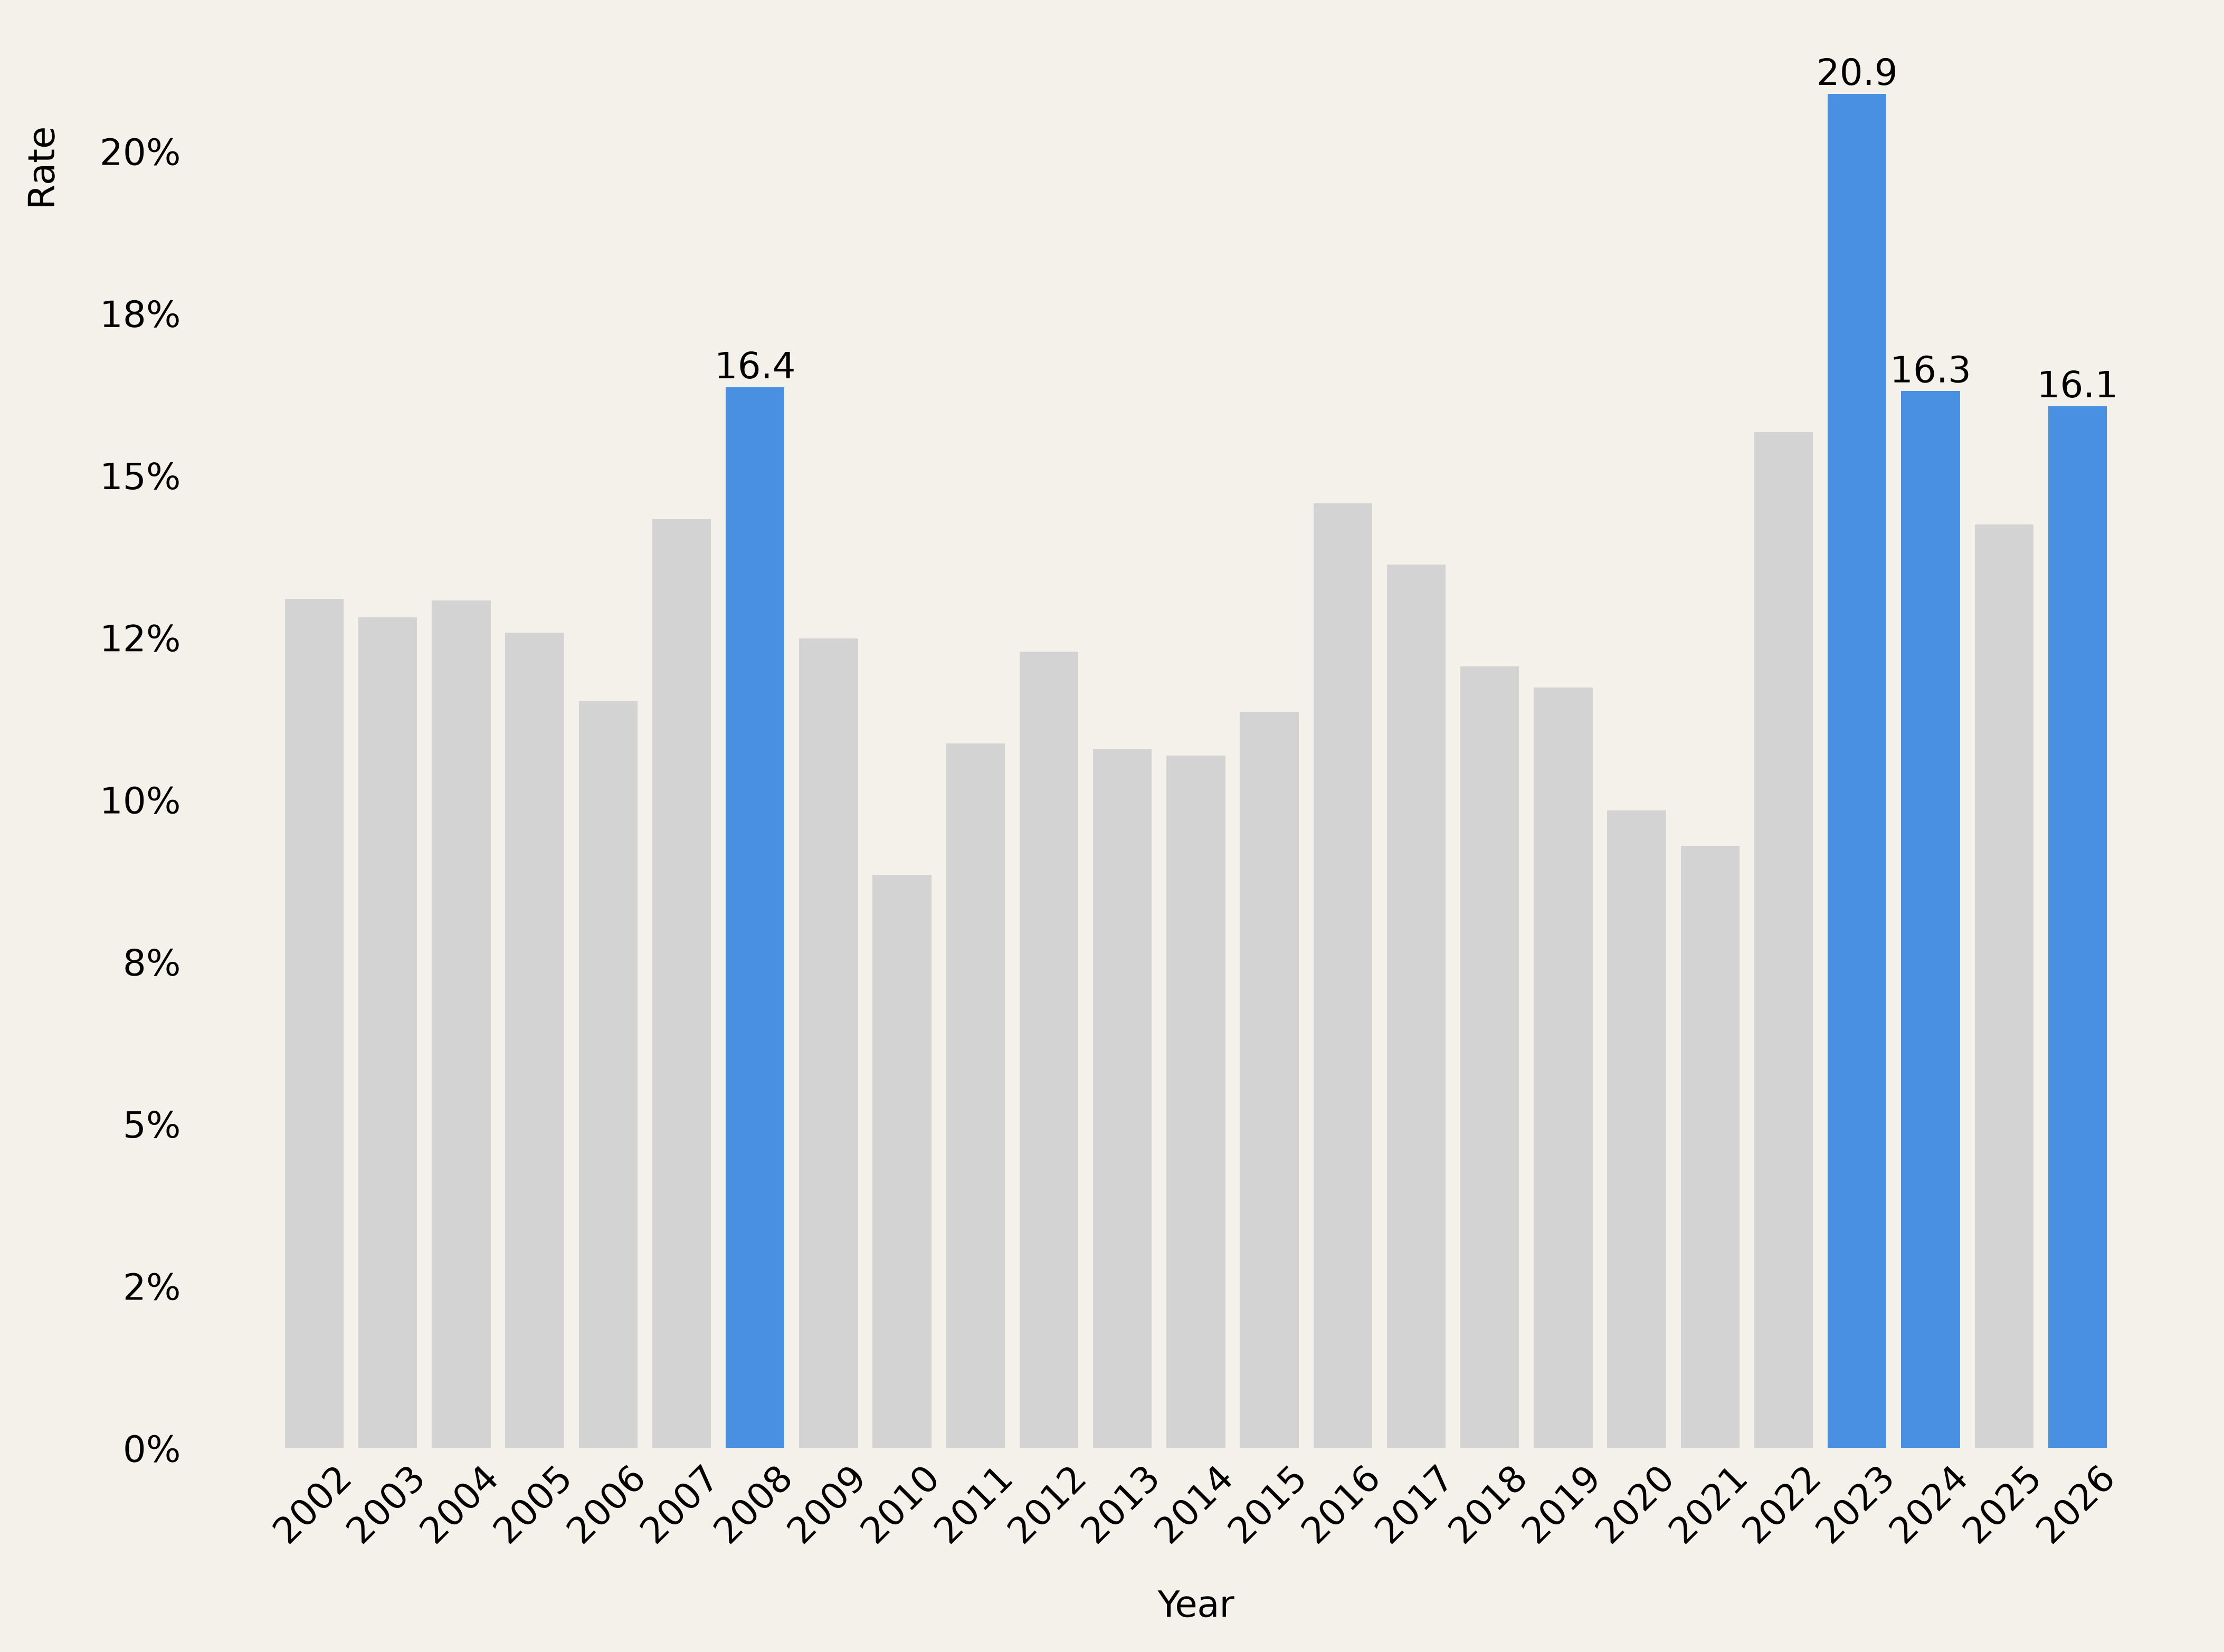

In [46]:
background = "#F4F1EA"
blue = "#4a90e2"
gray = "#D3D3D3"
v_2026 = by_year.iloc[-1].values[0]

color = [blue if x >= v_2026 else gray for x in by_year.values]

fig, ax = plt.subplots(figsize=(9.8, 7.0), dpi=500)
fig.patch.set_facecolor(background)
ax.patch.set_facecolor(background)

bars = plt.bar(by_year.index, by_year["Tasa (%)"], color=color)

for bar in bars:
    height = bar.get_height()
    if height >= v_2026:
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f"{height:.1f}",
                ha='center', va='bottom')

plt.xticks(by_year.index, rotation=45)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for side in ["top", "bottom", "left", "right"]:
    plt.gca().spines[side].set_visible(False)

for axis in ["y", "x"]:
    plt.tick_params(axis=axis, length=0)

plt.ylabel("Rate", labelpad=10, fontsize=10, y=0.9)
plt.xlabel("Year", labelpad=10, fontsize=10)

plt.show()